# Fake News Detection — BERT Fine-Tuning (Complete & Corrected)

**Pipeline overview:**
1. Install dependencies
2. Load & explore data
3. Preprocessing (correct order, no stemming)
4. Stratified train / val / test split
5. Tokenisation (fit on train only)
6. BERT fine-tuning with warmup + early stopping
7. Evaluation — F1, precision, recall, AUC-ROC, confusion matrix
8. Explainability with LIME
9. Save model

> **Dataset expected:** `Fake.csv` and `True.csv` (ISOT Fake News dataset)  
> Each file must have at least a `text` column.

## 1. Install Dependencies

In [1]:
!pip install -q transformers datasets scikit-learn torch lime
!pip install -q spacy
!python -m spacy download en_core_web_sm -q

# Verify GPU availability
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 79.9 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

## 2. Imports

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, matthews_corrcoef
)

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])  # only need lemmatizer

import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 3. Load Data

In [3]:

MODEL_SAVE_PATH = '/kaggle/working/bert_finetuned/'


# ── Load CSVs ────────────────────────────────────────────────────────────────
fake_df = pd.read_csv('/kaggle/input/datasets/abhishek162kumar/fakenews/Fake.csv')
true_df = pd.read_csv('/kaggle/input/datasets/abhishek162kumar/truenews/True.csv')

print(f"Fake articles: {len(fake_df):,}")
print(f"True articles: {len(true_df):,}")
print("\nFake columns:", fake_df.columns.tolist())
print("True columns: ", true_df.columns.tolist())

Fake articles: 23,481
True articles: 21,417

Fake columns: ['title', 'text', 'subject', 'date']
True columns:  ['title', 'text', 'subject', 'date']


## 4. Exploratory Data Analysis

Total samples: 44898

Label distribution:
label
Fake    23481
Real    21417
Name: count, dtype: int64


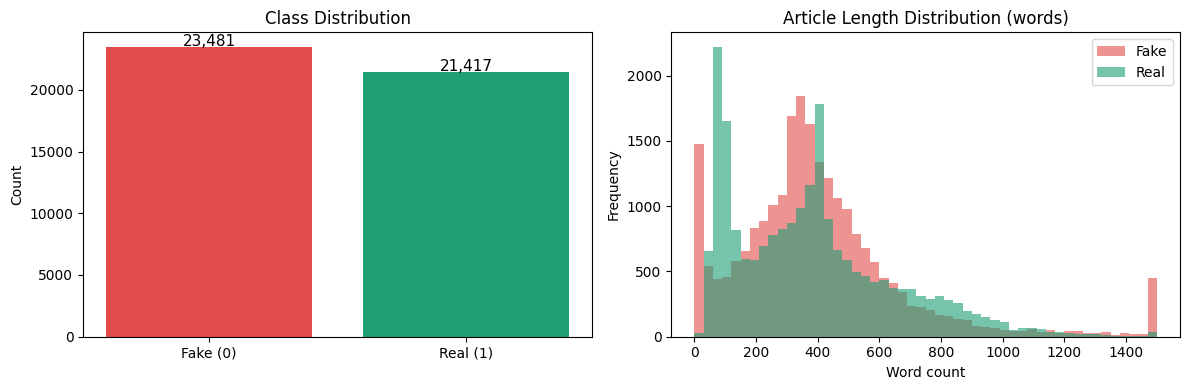


Median article length — Fake: 363 words
Median article length — Real: 359 words


In [4]:
# ── Label and combine ────────────────────────────────────────────────────────
fake_df['label'] = 0   # 0 = Fake
true_df['label'] = 1   # 1 = Real

df_raw = pd.concat([fake_df, true_df], ignore_index=True)

# ── Basic stats ──────────────────────────────────────────────────────────────
print("Total samples:", len(df_raw))
print("\nLabel distribution:")
print(df_raw['label'].value_counts().rename({0: 'Fake', 1: 'Real'}))

# ── Text length distribution ─────────────────────────────────────────────────
df_raw['text_length'] = df_raw['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
axes[0].bar(['Fake (0)', 'Real (1)'],
            df_raw['label'].value_counts().sort_index(),
            color=['#E24B4A', '#1D9E75'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{int(bar.get_height()):,}',
                 ha='center', fontsize=11)

# Text length by class
for label, color, name in [(0, '#E24B4A', 'Fake'), (1, '#1D9E75', 'Real')]:
    subset = df_raw[df_raw['label'] == label]['text_length']
    axes[1].hist(subset.clip(upper=1500), bins=50, alpha=0.6, color=color, label=name)
axes[1].set_title('Article Length Distribution (words)')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMedian article length — Fake: {df_raw[df_raw.label==0].text_length.median():.0f} words")
print(f"Median article length — Real: {df_raw[df_raw.label==1].text_length.median():.0f} words")

## 5. Preprocessing

**Rules applied here:**
- Remove boilerplate datelines (e.g. `WASHINGTON (Reuters) —`)
- Strip URLs, HTML tags, special characters
- Lowercase
- Lemmatize with spaCy (**no stemming** — stemming corrupts tokens before BERT sees them)
- **Stopwords are kept** — BERT needs them for grammar context ("not", "but", "no" change meaning)
- Collapse extra whitespace

In [5]:
# ── Boilerplate patterns common in ISOT dataset ───────────────────────────────
DATELINE_RE = re.compile(
    r'^[A-Z][A-Z\s,\.]+\([^)]+\)\s*[-–—]\s*',  # e.g. "WASHINGTON (Reuters) - "
    re.MULTILINE
)
URL_RE       = re.compile(r'https?://\S+|www\.\S+')
HTML_RE      = re.compile(r'<[^>]+>')
SPECIAL_RE   = re.compile(r'[^a-z\s]')           # keep only lowercase letters + spaces
WHITESPACE_RE= re.compile(r'\s+')


def preprocess(text: str) -> str:
    """
    Full preprocessing pipeline for fake news articles.
    Returns a clean, lemmatised string ready for BERT tokenisation.

    Steps:
        1. Cast to string (handles NaN)
        2. Remove dateline boilerplate
        3. Remove URLs and HTML
        4. Lowercase
        5. Remove non-alphabetic characters
        6. Collapse whitespace
        7. Lemmatise with spaCy (NO stemming)
           Stopwords are intentionally kept for BERT.
    """
    text = str(text)
    text = DATELINE_RE.sub('', text)          # strip dateline
    text = URL_RE.sub(' ', text)              # remove URLs
    text = HTML_RE.sub(' ', text)             # remove HTML tags
    text = text.lower()                       # lowercase
    text = SPECIAL_RE.sub(' ', text)          # keep letters + spaces only
    text = WHITESPACE_RE.sub(' ', text).strip()

    # Lemmatise — pipe processes in batch; disable unneeded components
    doc = nlp(text)
    text = ' '.join(token.lemma_ for token in doc)

    return text


# ── Demo on one article ───────────────────────────────────────────────────────
sample_raw = df_raw['text'].iloc[0]
print("RAW (first 300 chars):", sample_raw[:300])
print("\nCLEAN:", preprocess(sample_raw)[:300])

RAW (first 300 chars): Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger a

CLEAN: donald trump just couldn t wish all americans a happy new year and leave it at that instead he have to give a shout out to his enemy hater and the very dishonest fake news medium the former reality show star have just one job to do and he couldn t do it as our country rapidly grow strong and smart I


In [6]:
# ── Drop rows where text is missing or empty ──────────────────────────────────
df_raw = df_raw.dropna(subset=['text'])
df_raw = df_raw[df_raw['text'].str.strip() != '']

# ── Apply preprocessing (uses spaCy nlp.pipe for speed) ──────────────────────
print("Preprocessing text... (this may take a few minutes)")

# Batch preprocessing is much faster than row-by-row apply
def batch_preprocess(texts, batch_size=512):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        # Apply non-spaCy steps first
        batch_clean = [
            WHITESPACE_RE.sub(' ',
                SPECIAL_RE.sub(' ',
                    URL_RE.sub(' ',
                        HTML_RE.sub(' ',
                            DATELINE_RE.sub('', str(t))
                        )
                    ).lower()
                )
            ).strip()
            for t in batch
        ]
        # Lemmatise in batch
        for doc in nlp.pipe(batch_clean, batch_size=128):
            results.append(' '.join(token.lemma_ for token in doc))
        print(f"  Processed {min(i+batch_size, len(texts)):,} / {len(texts):,}", end='\r')
    print()
    return results

df_raw['clean_text'] = batch_preprocess(df_raw['text'].tolist())

# Remove rows that became empty after cleaning
df_raw = df_raw[df_raw['clean_text'].str.strip() != '']
df = df_raw[['clean_text', 'label']].reset_index(drop=True)

print(f"\nFinal dataset: {len(df):,} samples")
print(df['label'].value_counts().rename({0:'Fake', 1:'Real'}))

Preprocessing text... (this may take a few minutes)
  Processed 44,267 / 44,267

Final dataset: 44,183 samples
label
Fake    22767
Real    21416
Name: count, dtype: int64


## 6. Train / Validation / Test Split

**Strategy:** 80 % train — 10 % validation — 10 % test, stratified by label.

The split happens **before** any vectorisation or tokenisation to prevent data leakage.

In [7]:
# Step 1: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=RANDOM_SEED
)

# Step 2: 50% of temp → val, 50% → test  (each = 10% of total)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=RANDOM_SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train:      {len(train_df):,} samples  (Fake: {(train_df.label==0).sum():,} | Real: {(train_df.label==1).sum():,})")
print(f"Validation: {len(val_df):,}  samples  (Fake: {(val_df.label==0).sum():,}  | Real: {(val_df.label==1).sum():,})")
print(f"Test:       {len(test_df):,}  samples  (Fake: {(test_df.label==0).sum():,}  | Real: {(test_df.label==1).sum():,})")

Train:      35,346 samples  (Fake: 18,213 | Real: 17,133)
Validation: 4,418  samples  (Fake: 2,277  | Real: 2,141)
Test:       4,419  samples  (Fake: 2,277  | Real: 2,142)


## 7. Tokenisation

> **Important:** The tokeniser is **stateless** (it has a fixed vocabulary from pre-training),  
> so calling `tokenizer(...)` on train vs test produces consistent encodings automatically.  
> There is no `fit` step — no leakage risk here.  
> `max_length=512` is BERT's hard limit; longer articles are truncated from the end.

In [8]:
MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH = 512
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

class FakeNewsDataset(Dataset):
    """
    PyTorch Dataset for BERT sequence classification.
    Tokenises text on-the-fly so raw strings are stored (memory efficient).
    """
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = list(texts)
        self.labels     = list(labels)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),          # guard against non-string entries
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = FakeNewsDataset(train_df['clean_text'].tolist(), train_df['label'].tolist(), tokenizer, MAX_LENGTH)
val_dataset   = FakeNewsDataset(val_df['clean_text'].tolist(),   val_df['label'].tolist(),   tokenizer, MAX_LENGTH)
test_dataset  = FakeNewsDataset(test_df['clean_text'].tolist(),  test_df['label'].tolist(),  tokenizer, MAX_LENGTH)

print(f"Train dataset size: {len(train_dataset):,}")
print(f"Val   dataset size: {len(val_dataset):,}")
print(f"Test  dataset size: {len(test_dataset):,}")

# Quick sanity check — inspect one tokenised sample
sample = train_dataset[0]
print("\nSample input_ids shape:",     sample['input_ids'].shape)
print("Sample attention_mask shape:", sample['attention_mask'].shape)
print("Sample label:",                sample['labels'].item())

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train dataset size: 35,346
Val   dataset size: 4,418
Test  dataset size: 4,419

Sample input_ids shape: torch.Size([512])
Sample attention_mask shape: torch.Size([512])
Sample label: 1


## 8. Check for Class Imbalance & Compute Class Weights

In [9]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
cw      = compute_class_weight('balanced', classes=classes, y=train_df['label'].values)
class_weights = torch.tensor(cw, dtype=torch.float)

print(f"Class weights — Fake: {cw[0]:.4f}  |  Real: {cw[1]:.4f}")
if abs(cw[0] - cw[1]) < 0.05:
    print("Dataset is balanced — class weights are approximately equal.")
else:
    print("Dataset is imbalanced — weighted loss will be used during training.")

Class weights — Fake: 0.9704  |  Real: 1.0315
Dataset is imbalanced — weighted loss will be used during training.


## 9. Model, Metrics & Weighted Loss

In [10]:
# ── Load pre-trained BERT ──────────────────────────────────────────────────────
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'Fake', 1: 'Real'},
    label2id={'Fake': 0, 'Real': 1}
)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


# ── Metrics ────────────────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    """
    Returns accuracy, precision, recall, F1, MCC, and AUC-ROC.
    F1 (macro) is used as the primary metric for model selection.
    """
    logits, labels = eval_pred
    preds  = np.argmax(logits, axis=-1)
    proba  = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()[:, 1]

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    acc = accuracy_score(labels, preds)
    mcc = matthews_corrcoef(labels, preds)
    try:
        auc = roc_auc_score(labels, proba)
    except ValueError:
        auc = float('nan')

    return {
        'accuracy':  round(float(acc), 4),
        'f1':        round(float(f1), 4),
        'precision': round(float(precision), 4),
        'recall':    round(float(recall), 4),
        'mcc':       round(float(mcc), 4),
        'auc_roc':   round(float(auc), 4),
    }


# ── Custom Trainer with weighted cross-entropy ────────────────────────────────
class WeightedTrainer(Trainer):
    """
    Overrides compute_loss to apply class weights.
    Handles imbalanced datasets; has no effect when weights are equal.
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        weights = class_weights.to(logits.device)
        loss    = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 109,483,778
Trainable params: 109,483,778


## 10. Training Arguments

Key improvements over a basic setup:
- `warmup_ratio=0.1` — learning rate ramps up gently for first 10% of steps (prevents early aggressive updates)
- `EarlyStoppingCallback(patience=2)` — stops if val F1 doesn't improve for 2 evals
- `load_best_model_at_end=True` + `metric_for_best_model='f1'` — restores best checkpoint
- `fp16=True` — mixed precision halves GPU memory usage and speeds up training

In [11]:
import os
os.makedirs('./results', exist_ok=True)

training_args = TrainingArguments(
    output_dir='./results',

    # ── Evaluation & saving ──────────────────────────────────────────────────
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,

    # ── Optimiser ────────────────────────────────────────────────────────────
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    # ── Batch & epochs ───────────────────────────────────────────────────────
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    gradient_accumulation_steps=2,

    # ── Speed & memory ───────────────────────────────────────────────────────
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,

    # ── Logging ──────────────────────────────────────────────────────────────
    logging_steps=50,
    report_to='none',
    seed=RANDOM_SEED,

    # ── Checkpoint cleanup ───────────────────────────────────────────────────
    save_total_limit=2,             # keep only the 2 best checkpoints on disk
)

print("Training arguments configured.")
print(f"  Effective batch size:   {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Mixed precision (fp16): {training_args.fp16}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training arguments configured.
  Effective batch size:   32
  Mixed precision (fp16): True


## 11. Fine-Tune BERT

In [13]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2)
    ]
)

print("Starting training...")
train_result = trainer.train()

print("\nTraining complete.")
print(f"  Total steps:         {train_result.global_step}")
print(f"  Final training loss: {train_result.training_loss:.4f}")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Mcc,Auc Roc
1,0.082651,0.018728,0.994600,0.994600,0.994600,0.994500,0.989100,0.999500
2,0.028420,0.014514,0.997100,0.997100,0.997100,0.997000,0.994100,0.999700
3,0.014992,0.015254,0.996800,0.996800,0.996800,0.996900,0.993700,0.999800
4,0.006765,0.011449,0.998400,0.998400,0.998400,0.998400,0.996800,0.999900
5,0.000166,0.013520,0.998400,0.998400,0.998400,0.998400,0.996800,0.999900
6,0.000028,0.019274,0.997700,0.997700,0.997800,0.997700,0.995500,0.999900


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete.
  Total steps:         3318
  Final training loss: 0.0778


## 12. Training Curves

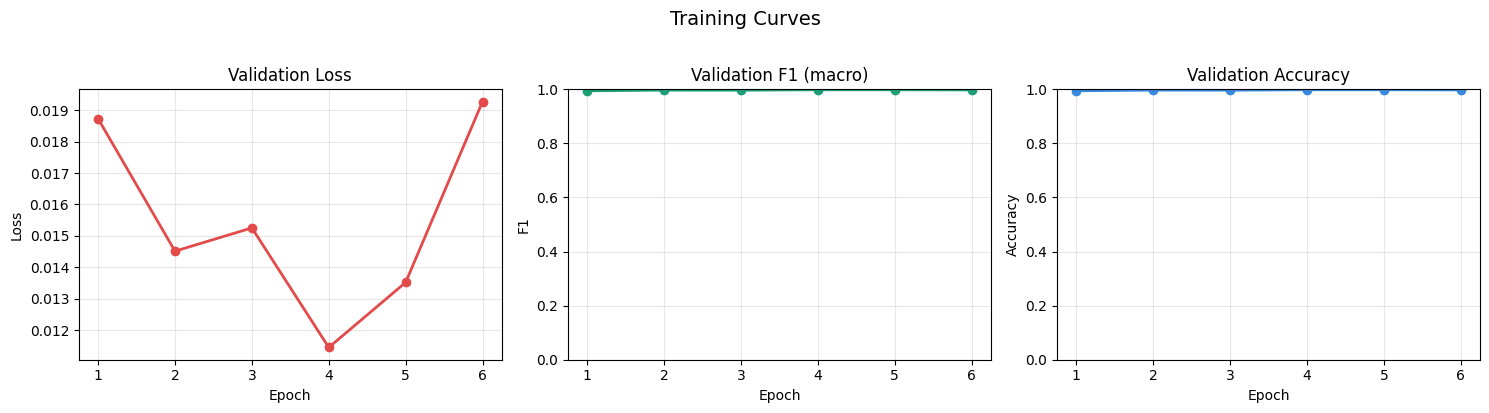

In [14]:
log_history = trainer.state.log_history

# Separate train and eval logs
train_logs = [l for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [l for l in log_history if 'eval_loss' in l]

if eval_logs:
    epochs   = [l['epoch'] for l in eval_logs]
    val_loss = [l['eval_loss'] for l in eval_logs]
    val_f1   = [l['eval_f1'] for l in eval_logs]
    val_acc  = [l['eval_accuracy'] for l in eval_logs]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, val_loss, 'o-', color='#E24B4A', linewidth=2)
    axes[0].set_title('Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, val_f1, 'o-', color='#1D9E75', linewidth=2)
    axes[1].set_title('Validation F1 (macro)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1')
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)

    axes[2].plot(epochs, val_acc, 'o-', color='#378ADD', linewidth=2)
    axes[2].set_title('Validation Accuracy')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy')
    axes[2].set_ylim(0, 1)
    axes[2].grid(alpha=0.3)

    plt.suptitle('Training Curves', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 13. Evaluate on Held-Out Test Set

The test set has **never been seen** during training or hyperparameter selection.

In [15]:
# ── Get raw predictions ───────────────────────────────────────────────────────
pred_output  = trainer.predict(test_dataset)
logits       = pred_output.predictions
y_true       = pred_output.label_ids
y_pred       = np.argmax(logits, axis=-1)
y_proba      = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_true, y_pred)
mcc  = matthews_corrcoef(y_true, y_pred)
auc  = roc_auc_score(y_true, y_proba)
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("=" * 50)
print("         TEST SET EVALUATION")
print("=" * 50)
print(f"  Accuracy:             {acc:.4f}")
print(f"  F1 (macro):           {f1:.4f}")
print(f"  Precision (macro):    {p:.4f}")
print(f"  Recall (macro):       {r:.4f}")
print(f"  MCC:                  {mcc:.4f}")
print(f"  AUC-ROC:              {auc:.4f}")
print("=" * 50)
print()
print("Per-class report:")
print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

         TEST SET EVALUATION
  Accuracy:             0.9977
  F1 (macro):           0.9977
  Precision (macro):    0.9977
  Recall (macro):       0.9977
  MCC:                  0.9955
  AUC-ROC:              1.0000

Per-class report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2277
        Real       1.00      1.00      1.00      2142

    accuracy                           1.00      4419
   macro avg       1.00      1.00      1.00      4419
weighted avg       1.00      1.00      1.00      4419



## 14. Confusion Matrix

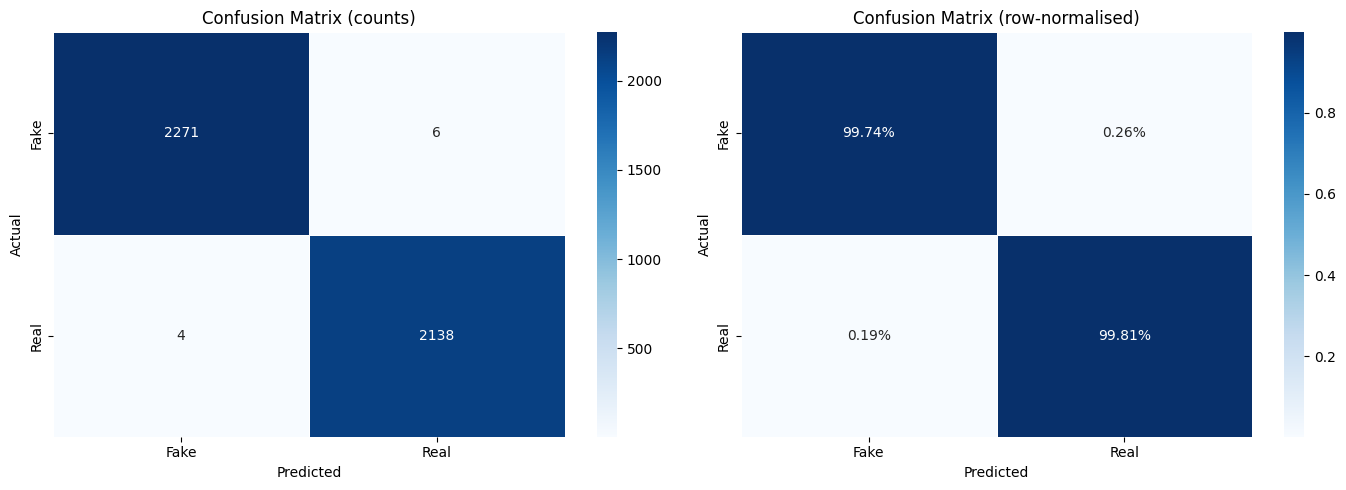

True Negatives  (Fake → Fake): 2,271
False Positives (Fake → Real): 6  ← real news flagged as fake
False Negatives (Real → Fake): 4  ← fake news missed
True Positives  (Real → Real): 2,138


In [16]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real'],
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Normalised (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real'],
    ax=axes[1], linewidths=0.5
)
axes[1].set_title('Confusion Matrix (row-normalised)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Fake → Fake): {tn:,}")
print(f"False Positives (Fake → Real): {fp:,}  ← real news flagged as fake")
print(f"False Negatives (Real → Fake): {fn:,}  ← fake news missed")
print(f"True Positives  (Real → Real): {tp:,}")

## 15. ROC Curve

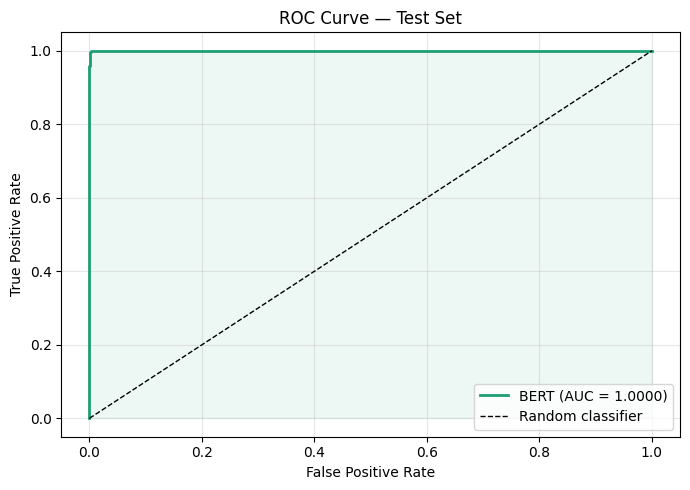

In [17]:
fpr, tpr, thresholds = roc_curve(y_true, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#1D9E75', lw=2, label=f'BERT (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='#1D9E75')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Explainability with LIME

LIME (Local Interpretable Model-agnostic Explanations) perturbs a single article  
and observes how predictions change — revealing which words drove the decision.

In [18]:
from lime.lime_text import LimeTextExplainer

lime_explainer = LimeTextExplainer(class_names=['Fake', 'Real'])


def predict_proba_for_lime(texts):
    """Wraps the BERT model for LIME — returns [P(Fake), P(Real)] for each text."""
    model.eval()
    device = next(model.parameters()).device
    all_probs = []

    for text in texts:
        enc = tokenizer(
            text, return_tensors='pt',
            padding='max_length', truncation=True, max_length=MAX_LENGTH
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        all_probs.append(probs)

    return np.array(all_probs)


# ── Pick one fake and one real article for explanation ────────────────────────
fake_idx = test_df[test_df['label'] == 0].index[0]
real_idx = test_df[test_df['label'] == 1].index[0]

for idx, name in [(fake_idx, 'FAKE'), (real_idx, 'REAL')]:
    article  = test_df.loc[idx, 'clean_text']
    true_lbl = test_df.loc[idx, 'label']
    pred_lbl = y_pred[list(test_df.index).index(idx)]

    print(f"\n{'='*60}")
    print(f"Article: {name} | True label: {true_lbl} | Predicted: {pred_lbl}")
    print(f"Text preview: {article[:200]}...")

    exp = lime_explainer.explain_instance(
        article,
        predict_proba_for_lime,
        num_features=12,
        num_samples=300       # increase for more stable explanations
    )

    print(f"\nTop influential words (positive = towards Real, negative = towards Fake):")
    for word, weight in exp.as_list():
        direction = 'Real ↑' if weight > 0 else 'Fake ↑'
        print(f"  {word:30s}  {weight:+.4f}  ({direction})")


Article: FAKE | True label: 0 | Predicted: 0
Text preview: donald trump be currently lead in the poll in new york state but he win t be receive two vote from his own kid on monday donald trump admit his son eric and daughter ivanka forget to register to vote ...

Top influential words (positive = towards Real, negative = towards Fake):
  out                             -0.0008  (Fake ↑)
  who                             -0.0007  (Fake ↑)
  now                             -0.0007  (Fake ↑)
  america                         -0.0007  (Fake ↑)
  april                           +0.0006  (Real ↑)
  fascist                         -0.0005  (Fake ↑)
  s                               +0.0005  (Real ↑)
  so                              +0.0005  (Real ↑)
  on                              +0.0005  (Real ↑)
  oversight                       +0.0004  (Real ↑)
  a                               +0.0003  (Real ↑)
  can                             +0.0003  (Real ↑)

Article: REAL | True label: 1 | Pred

## 17. LIME HTML Visualisation 

In [19]:
from IPython.display import display, HTML

# Explain the first fake article
article = test_df.loc[fake_idx, 'clean_text']
exp = lime_explainer.explain_instance(
    article, predict_proba_for_lime,
    num_features=15, num_samples=500
)

display(HTML(exp.as_html()))

## 18. Custom Inference Function

In [20]:
def predict_article(text: str, explain: bool = False):
    """
    Predict whether a news article is fake or real.

    Args:
        text:    Raw article text (preprocessing is applied automatically).
        explain: If True, prints top LIME word attributions.

    Returns:
        dict with label, confidence, and probabilities.
    """
    model.eval()
    device = next(model.parameters()).device

    clean    = preprocess(text)
    encoding = tokenizer(
        clean, return_tensors='pt',
        padding='max_length', truncation=True, max_length=MAX_LENGTH
    )
    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        logits = model(**encoding).logits

    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred  = int(np.argmax(probs))
    label = 'Real' if pred == 1 else 'Fake'

    result = {
        'prediction':  label,
        'confidence':  round(float(probs[pred]) * 100, 2),
        'P(Fake)':     round(float(probs[0]) * 100, 2),
        'P(Real)':     round(float(probs[1]) * 100, 2),
    }

    print(f"Prediction : {result['prediction']}")
    print(f"Confidence : {result['confidence']:.2f}%")
    print(f"P(Fake)    : {result['P(Fake)']:.2f}%")
    print(f"P(Real)    : {result['P(Real)']:.2f}%")

    if explain:
        exp = lime_explainer.explain_instance(
            clean, predict_proba_for_lime,
            num_features=10, num_samples=300
        )
        print("\nKey words driving the prediction:")
        for word, weight in exp.as_list():
            print(f"  {word:30s}  {weight:+.4f}")

    return result


# ── Demo ──────────────────────────────────────────────────────────────────────
sample_text = """
Scientists have confirmed a new vaccine candidate shows over 90 percent efficacy
in phase 3 trials, according to peer-reviewed results published in the Lancet.
The trial involved 30,000 participants across 12 countries.
"""

print("=" * 50)
print("Demo prediction")
print("=" * 50)
_ = predict_article(sample_text, explain=False)

Demo prediction
Prediction : Real
Confidence : 99.98%
P(Fake)    : 0.02%
P(Real)    : 99.98%


## 19. Save Model & Tokeniser

In [21]:
import os, json
import numpy as np
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# ── Model & tokenizer ─────────────────────────────────────────────────────────
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

# ── Metrics JSON ──────────────────────────────────────────────────────────────
metrics = {
    'accuracy':   round(float(acc), 4),
    'f1_macro':   round(float(f1),  4),
    'precision':  round(float(p),   4),
    'recall':     round(float(r),   4),
    'mcc':        round(float(mcc), 4),
    'auc_roc':    round(float(auc), 4),
    'test_size':  int(len(test_df)),
    'model':      MODEL_NAME,
    'max_length': MAX_LENGTH,
    'epochs_run': int(trainer.state.global_step //
                      max(1, len(train_dataset) // training_args.per_device_train_batch_size)),
    'best_val_f1': round(float(trainer.state.best_metric or 0), 4),
}
with open(MODEL_SAVE_PATH + 'test_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# ── Raw predictions (needed for exact ROC curves in comparison notebook) ──────
np.save(MODEL_SAVE_PATH + 'y_test.npy',  y_true.astype(np.int32))
np.save(MODEL_SAVE_PATH + 'y_pred.npy',  y_pred.astype(np.int32))
np.save(MODEL_SAVE_PATH + 'y_proba.npy', y_proba.astype(np.float32))

# ── Training log ──────────────────────────────────────────────────────────────
log_path = MODEL_SAVE_PATH + 'training_log.json'
with open(log_path, 'w') as f:
    json.dump(trainer.state.log_history, f, indent=2)

# ── Verify everything was written ─────────────────────────────────────────────
print(f'Model saved to: {MODEL_SAVE_PATH}')
print(f'\n{"File":<40s}  {"Size":>10s}')
print('-' * 55)
for fname in sorted(os.listdir(MODEL_SAVE_PATH)):
    fpath = MODEL_SAVE_PATH + fname
    size  = os.path.getsize(fpath)
    unit  = 'MB' if size > 1e6 else 'KB'
    val   = size / 1e6 if size > 1e6 else size / 1024
    print(f'  {fname:<38s}  {val:6.1f} {unit}')

print('\ntest_metrics.json contents:')
for k, v in metrics.items():
    print(f'  {k:<15s}: {v}')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/bert_finetuned/

File                                            Size
-------------------------------------------------------
  config.json                                0.8 KB
  model.safetensors                        438.0 MB
  test_metrics.json                          0.2 KB
  tokenizer.json                           695.0 KB
  tokenizer_config.json                      0.3 KB
  training_log.json                         13.5 KB
  y_pred.npy                                17.4 KB
  y_proba.npy                               17.4 KB
  y_test.npy                                17.4 KB

test_metrics.json contents:
  accuracy       : 0.9977
  f1_macro       : 0.9977
  precision      : 0.9977
  recall         : 0.9977
  mcc            : 0.9955
  auc_roc        : 1.0
  test_size      : 4419
  model          : bert-base-uncased
  max_length     : 512
  epochs_run     : 1
  best_val_f1    : 0.9984


## 20. Quick Sanity Check — Reload & Verify Saved Artefacts

Confirms every file was written correctly and the reloaded model
produces identical predictions to the in-memory model.

In [22]:
import json, numpy as np
from transformers import BertTokenizerFast, BertForSequenceClassification

# ── 1. Reload saved files ─────────────────────────────────────────────────────
with open(MODEL_SAVE_PATH + 'test_metrics.json') as f:
    saved_metrics = json.load(f)

saved_y_test  = np.load(MODEL_SAVE_PATH + 'y_test.npy')
saved_y_pred  = np.load(MODEL_SAVE_PATH + 'y_pred.npy')
saved_y_proba = np.load(MODEL_SAVE_PATH + 'y_proba.npy')

# ── 2. Array integrity checks ─────────────────────────────────────────────────
assert len(saved_y_test)  == saved_metrics['test_size'], 'y_test length mismatch'
assert len(saved_y_pred)  == saved_metrics['test_size'], 'y_pred length mismatch'
assert len(saved_y_proba) == saved_metrics['test_size'], 'y_proba length mismatch'
assert saved_y_proba.min() >= 0 and saved_y_proba.max() <= 1, 'y_proba out of [0,1]'
print('Array integrity  : OK')

# ── 3. Metrics consistency check ─────────────────────────────────────────────
from sklearn.metrics import accuracy_score
recomputed_acc = round(accuracy_score(saved_y_test, saved_y_pred), 4)
assert recomputed_acc == saved_metrics['accuracy'], \
    f'Accuracy mismatch: saved={saved_metrics["accuracy"]} recomputed={recomputed_acc}'
print('Metrics consistency: OK')

# ── 4. Reload model and run one forward pass ──────────────────────────────────
loaded_tok   = BertTokenizerFast.from_pretrained(MODEL_SAVE_PATH)
loaded_model = BertForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)
loaded_model.eval()

sample_text = test_df['clean_text'].iloc[0]
enc = loaded_tok(sample_text, return_tensors='pt',
                 padding='max_length', truncation=True, max_length=MAX_LENGTH)
import torch
with torch.no_grad():
    logits = loaded_model(**enc).logits
prob   = torch.softmax(logits, dim=-1)[0].tolist()
print(f'Reload model     : OK  (sample P(Fake)={prob[0]:.4f}  P(Real)={prob[1]:.4f})')

print()
print('All saved artefacts verified. Safe to use in comparison notebook.')


Array integrity  : OK
Metrics consistency: OK


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Reload model     : OK  (sample P(Fake)=0.0000  P(Real)=1.0000)

All saved artefacts verified. Safe to use in comparison notebook.


## 20. Load Saved Model (for future inference)

In [23]:
# Run this cell any time to load the saved model without retraining

loaded_tokenizer = BertTokenizerFast.from_pretrained(MODEL_SAVE_PATH)
loaded_model     = BertForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)
loaded_model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model = loaded_model.to(device)

print("Model loaded successfully from:", MODEL_SAVE_PATH)
print("Ready for inference.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully from: /kaggle/working/bert_finetuned/
Ready for inference.
